<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/CVAssignments_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Dataset Preparation (4 marks):**

•	Use labelling tools (Ex. CVAT) to annotate the different types of objects as explained in Classes in each bin.

•	Export the dataset in a suitable format. Ex. YOLO

•	Dataset Split: Split the dataset into a 90-10 split: 90% for training and 10% for testing. Ensure the test split has at-least 7 bad images.


**Part 1 **focuses on environment setup, dataset verification, and splitting the dataset.

Assumptions

Dataset is already annotated in YOLO format.

Current structure:

PushPinDataSets/
└── train/
    ├── images/
    └── labels/

Total dataset = 216 images

Training = 170

Validation = 23

Test = 23

After running this notebook, the dataset structure will become:

PushPinDataSets/
│
├── train/
│   ├── images
│   └── labels
│
├── valid/
│   ├── images
│   └── labels
│
├── test/
│   ├── images
│   └── labels
│
└── dataset.yaml


**Part 1 : Dataset Preparation**

**Cell 1 : Install Required Libraries**

In [28]:
# Install Ultralytics YOLO
!pip install ultralytics -q
!pip install opencv-python -q
!pip install matplotlib -q
!pip install seaborn -q
!pip install pandas -q
!pip install scikit-learn -q

In [30]:
!unzip PushPinDataSets.zip

Archive:  PushPinDataSets.zip
replace PushPinDataSets/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: All
  inflating: PushPinDataSets/data.yaml  
  inflating: PushPinDataSets/test/images/bad_000.png  
  inflating: PushPinDataSets/test/images/bad_010.png  
  inflating: PushPinDataSets/test/images/bad_020.png  
  inflating: PushPinDataSets/test/images/bad_030.png  
  inflating: PushPinDataSets/test/images/bad_040.png  
  inflating: PushPinDataSets/test/images/bad_050.png  
  inflating: PushPinDataSets/test/images/bad_060.png  
  inflating: PushPinDataSets/test/images/bad_070.png  
  inflating: PushPinDataSets/test/images/bad_080.png  
  inflating: PushPinDataSets/test/images/bad_090.png  
  inflating: PushPinDataSets/test/images/bad_100.png  
  inflating: PushPinDataSets/test/images/bad_110.png  
  inflating: PushPinDataSets/test/images/bad_120.png  
  inflating: PushPinDataSets/test/images/bad_130.png  
  inflating: PushPinDataSets/test/images/bad_140.png  
  inflating: PushPinDataSet

**Cell 2 : Import Libraries**

In [31]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from collections import Counter
from sklearn.model_selection import train_test_split

**Cell 3 : Dataset Path**

In [32]:
DATASET_PATH = "PushPinDataSets"

SOURCE_IMAGES = os.path.join(DATASET_PATH,"train","images")
SOURCE_LABELS = os.path.join(DATASET_PATH,"train","labels")

print(SOURCE_IMAGES)
print(SOURCE_LABELS)

PushPinDataSets/train/images
PushPinDataSets/train/labels


**Cell 4 : Define Classes**

In [33]:
CLASS_NAMES = {

0:"1_pin",

1:"2_pin",

2:"3_pin",

3:"missing_pin",

4:"front_bend",

5:"broken",

6:"wrong_color",

7:"contamination",

8:"missing_separator"

}

**Cell 5 : Verify Dataset**

In [34]:
images = sorted(glob(os.path.join(SOURCE_IMAGES,"*.jpg")))

if len(images)==0:
    images = sorted(glob(os.path.join(SOURCE_IMAGES,"*.png")))

labels = sorted(glob(os.path.join(SOURCE_LABELS,"*.txt")))

print("Images :",len(images))
print("Labels :",len(labels))

Images : 170
Labels : 170


**Cell 6 : Count Objects**

In [35]:
counter=Counter()

total_objects=0

for label in labels:

    with open(label) as f:

        lines=f.readlines()

    total_objects+=len(lines)

    for line in lines:

        cls=int(line.split()[0])

        counter[cls]+=1

print("Total Objects :",total_objects)

Total Objects : 286


**Cell 7 : Plot Class Distribution**

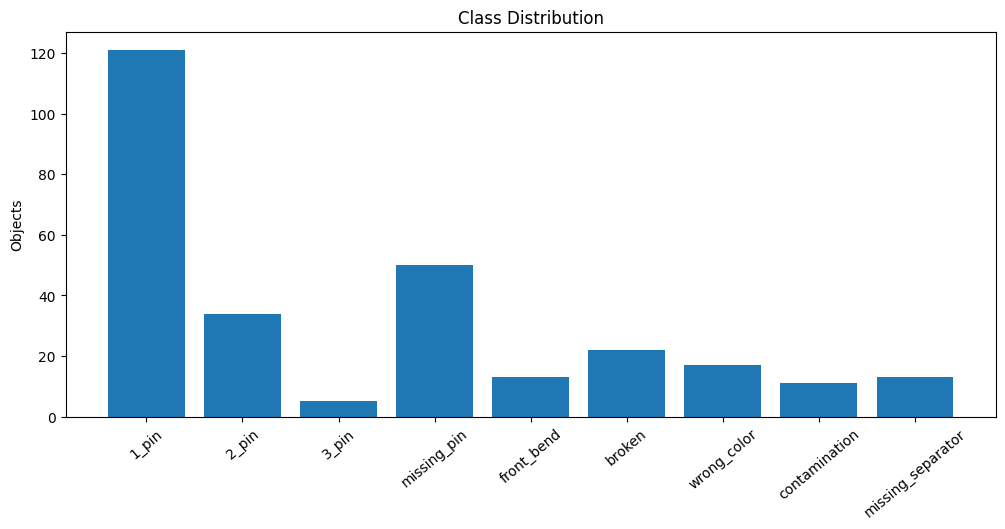

In [36]:
classes=[]
counts=[]

for i in CLASS_NAMES:

    classes.append(CLASS_NAMES[i])

    counts.append(counter[i])

plt.figure(figsize=(12,5))

plt.bar(classes,counts)

plt.xticks(rotation=40)

plt.title("Class Distribution")

plt.ylabel("Objects")

plt.show()

**Cell 8 : Verify Split**

In [37]:
print("Train Images :",len(glob(DATASET_PATH+"/train/images/*")))

print("Validation Images :",len(glob(DATASET_PATH+"/valid/images/*")))

print("Test Images :",len(glob(DATASET_PATH+"/test/images/*")))

Train Images : 170
Validation Images : 23
Test Images : 23


**Cell 9 : Display dataset.yaml**

In [39]:
with open("/content/PushPinDataSets/data.yaml","r") as f:

    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 9
names: ['1_pin', '2_pin', '3_pin','missing_pin','front_bend','broken','wrong_color','contamination','missing_separator']










**Cell 10 : Visualize Random Samples**

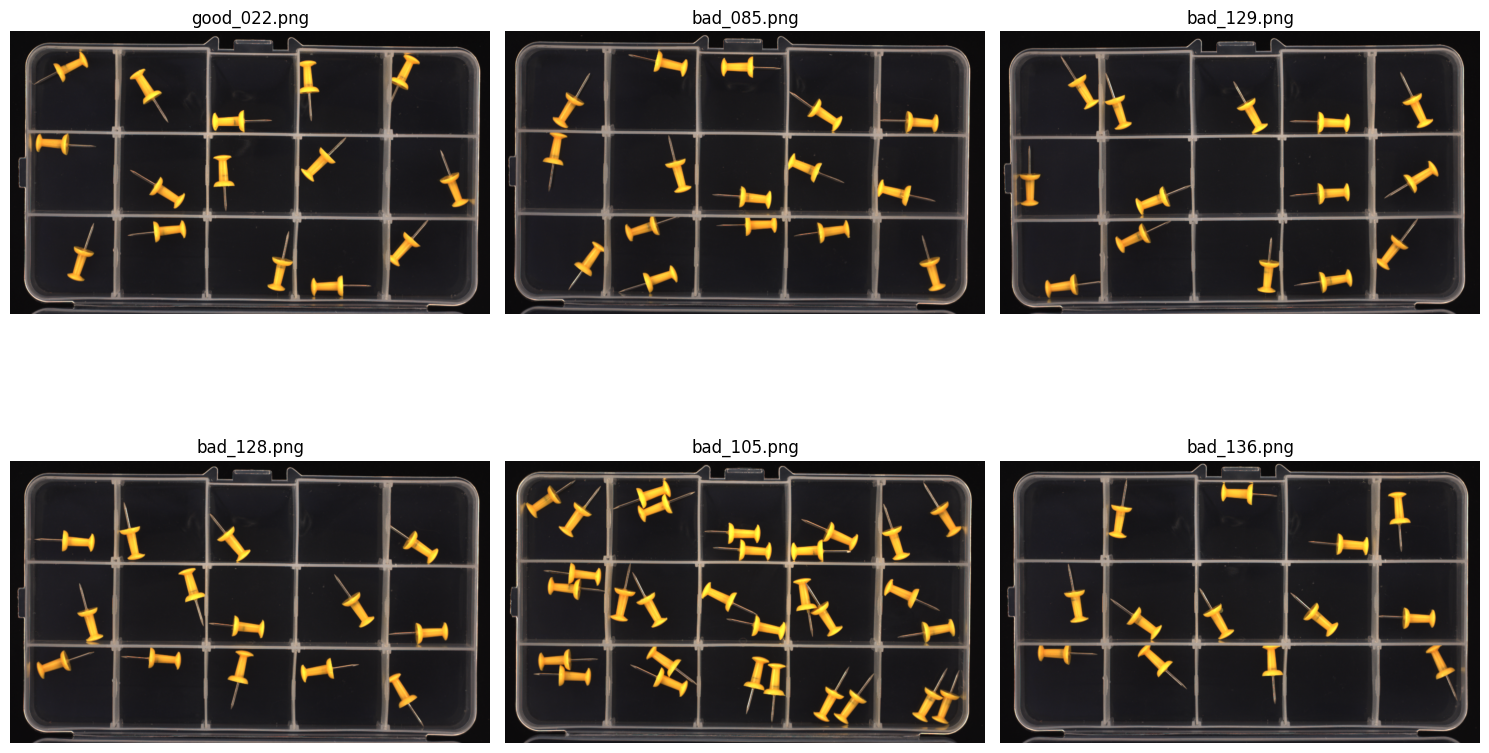

In [40]:
sample_images = random.sample(train_images, 6)

plt.figure(figsize=(15,10))

for i, img_path in enumerate(sample_images):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(os.path.basename(img_path))

    plt.axis("off")

plt.tight_layout()

plt.show()

**2.	Model Training (8 marks): **

•	Train an object detection model leveraging transfer learning by fine-tuning a pre-trained model. You can use any object detection framework such as Ultralytics YOLO (recommended).

•	Experiment with different architectures (YOLOv5, YOLOv8, etc.), data augmentation and hyperparameters.

•	Evaluate the models using mean average precision (mAP) or other relevant metrics.

•	Compare and select the best model from the experiments.


**Part 2 focuses on YOLOv5 Transfer Learning.**

It includes:

Clone YOLOv5 repository

Install dependencies

Load pretrained weights

Train with transfer learning

Data augmentation

Hyperparameter tuning

Save best model

Evaluate training results

Part 2 : YOLOv5 Model Training (Transfer Learning)

Cell 1 : Clone YOLOv5 Repository

In [1]:
# Clone YOLOv5 repository

!git clone https://github.com/ultralytics/yolov5

%cd yolov5

# !pip install -r requirements.txt

fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


In [2]:
# Cell 2 – Verify GPU
import torch

print("Torch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Torch Version : 2.11.0+cu128
CUDA Available : True
GPU : Tesla T4


In [4]:
# Cell 3 – Check Dataset
import yaml

yaml_file="/content/PushPinDataSets/data.yaml"

with open(yaml_file) as f:
    data=yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['1_pin', '2_pin', '3_pin', 'missing_pin', 'front_bend', 'broken', 'wrong_color', 'contamination', 'missing_separator']}


In [6]:
# Cell 4 – Display Dataset Information
print("Train :",data["train"])
print("Validation :",data["val"])
print("Test :",data["test"])

print("\nClasses")

for i,name in enumerate(data["names"]):
    print(i,name)

Train : ../train/images
Validation : ../valid/images
Test : ../test/images

Classes
0 1_pin
1 2_pin
2 3_pin
3 missing_pin
4 front_bend
5 broken
6 wrong_color
7 contamination
8 missing_separator


# **YOLOv8**

In [11]:
# ==========================================
# YOLOv8 Nano - Transfer Learning
# ==========================================

from ultralytics import YOLO

# Load pretrained model
model_n = YOLO("yolov8n.pt")

# Train
results_n = model_n.train(
    data="/content/PushPinDataSets/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    cache=True,
    workers=2,
    patience=20,
    project="PushPinModels",
    name="YOLOv8n"
)

# Validate
metrics_n = model_n.val()

# Test
test_metrics_n = model_n.val(split="test")

# Prediction
model_n.predict(
    source="/content/PushPinDataSets/test/images",
    save=True,
    conf=0.25
)

# Display Metrics
print("Precision :", metrics_n.box.mp)
print("Recall    :", metrics_n.box.mr)
print("mAP50     :", metrics_n.box.map50)
print("mAP50-95  :", metrics_n.box.map)

# Best Model Location
print("Best Model : PushPinModels/YOLOv8n/weights/best.pt")

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PushPinDataSets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p